# K-Nearest Neighbors (KNN) Model for Customer Churn Prediction

## Assignment Component: K-Nearest Neighbors (KNN) Algorithm

**Team Member:** Rashani K.G.M  
**Date:** March 29, 2026  
**Course:** Machine Learning Assignment

## 1. Introduction

This notebook implements the **K-Nearest Neighbors (KNN)** algorithm to predict telecom customer churn.

### What is KNN?
K-Nearest Neighbors is a supervised machine learning algorithm that:
- Stores all training cases (instance-based learning)
- Finds K closest data points based on distance (usually Euclidean)
- Assigns class based on majority vote among K neighbors
- Is simple yet effective for classification problems

## 2. Import Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the preprocessed dataset
X_train = pd.read_csv("../dataset/X_train.csv")
X_test = pd.read_csv("../dataset/X_test.csv")

y_train = pd.read_csv("../dataset/y_train.csv").values.ravel()
y_test = pd.read_csv("../dataset/y_test.csv").values.ravel()

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"\nTarget variable distribution:\n{pd.Series(y_train).value_counts()}")

Training data shape: (5625, 30)
Testing data shape: (1407, 30)

Target variable distribution:
False    4130
True     1495
Name: count, dtype: int64


## 3. Data Preprocessing - Feature Scaling

Data has been scaled using StandardScaler

SMOTE (Synthetic Minority Over-sampling Technique)
Before SMOTE:
False    4130
True     1495
Name: count, dtype: int64

After SMOTE:
True     4130
False    4130
Name: count, dtype: int64

✓ SMOTE applied successfully!


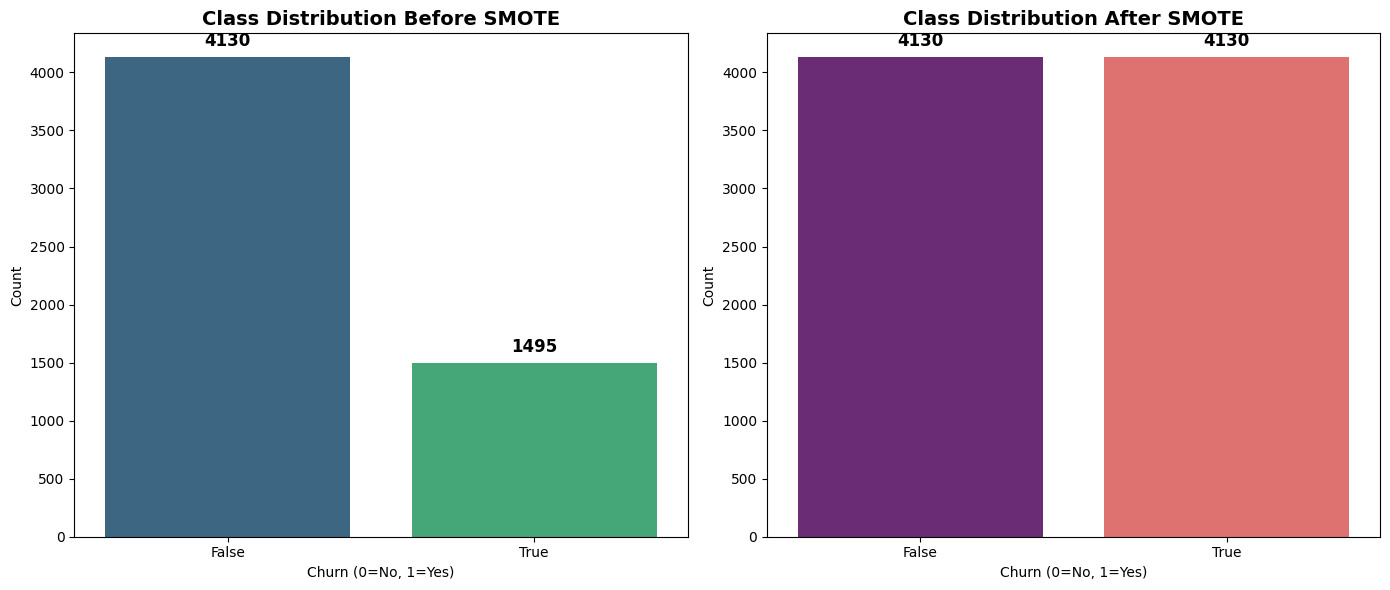

In [4]:
# Feature scaling is crucial for KNN since it's distance-based
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data has been scaled using StandardScaler")
# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\n" + "="*50)
print("SMOTE (Synthetic Minority Over-sampling Technique)")
print("="*50)
print("Before SMOTE:")
print(pd.Series(y_train).value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print("\n✓ SMOTE applied successfully!")

# Visualize Class Distribution Before and After SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before SMOTE
sns.countplot(x=y_train, ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution Before SMOTE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
for idx, v in enumerate(pd.Series(y_train).value_counts().values):
    axes[0].text(idx, v + 100, str(v), ha='center', fontsize=12, fontweight='bold')

# After SMOTE
sns.countplot(x=y_train_smote, ax=axes[1], palette='magma')
axes[1].set_title('Class Distribution After SMOTE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn (0=No, 1=Yes)')
axes[1].set_ylabel('Count')
for idx, v in enumerate(pd.Series(y_train_smote).value_counts().values):
    axes[1].text(idx, v + 100, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Finding the Optimal K Value

In [5]:
# Test different K values to find the best one
k_range = range(1, 31)
accuracy_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_smote, y_train_smote)  # Use SMOTE-balanced data
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    print(f"K={k}: Accuracy = {accuracy:.4f}")

K=1: Accuracy = 0.7043
K=2: Accuracy = 0.7186
K=3: Accuracy = 0.6851
K=4: Accuracy = 0.7157
K=5: Accuracy = 0.6752
K=6: Accuracy = 0.6951
K=7: Accuracy = 0.6752
K=8: Accuracy = 0.7029
K=9: Accuracy = 0.6759
K=10: Accuracy = 0.6979
K=11: Accuracy = 0.6830
K=12: Accuracy = 0.7015
K=13: Accuracy = 0.6908
K=14: Accuracy = 0.7036
K=15: Accuracy = 0.6837
K=16: Accuracy = 0.6965
K=17: Accuracy = 0.6816
K=18: Accuracy = 0.6951
K=19: Accuracy = 0.6773
K=20: Accuracy = 0.6951
K=21: Accuracy = 0.6802
K=22: Accuracy = 0.6901
K=23: Accuracy = 0.6759
K=24: Accuracy = 0.6873
K=25: Accuracy = 0.6745
K=26: Accuracy = 0.6844
K=27: Accuracy = 0.6716
K=28: Accuracy = 0.6787
K=29: Accuracy = 0.6674
K=30: Accuracy = 0.6759


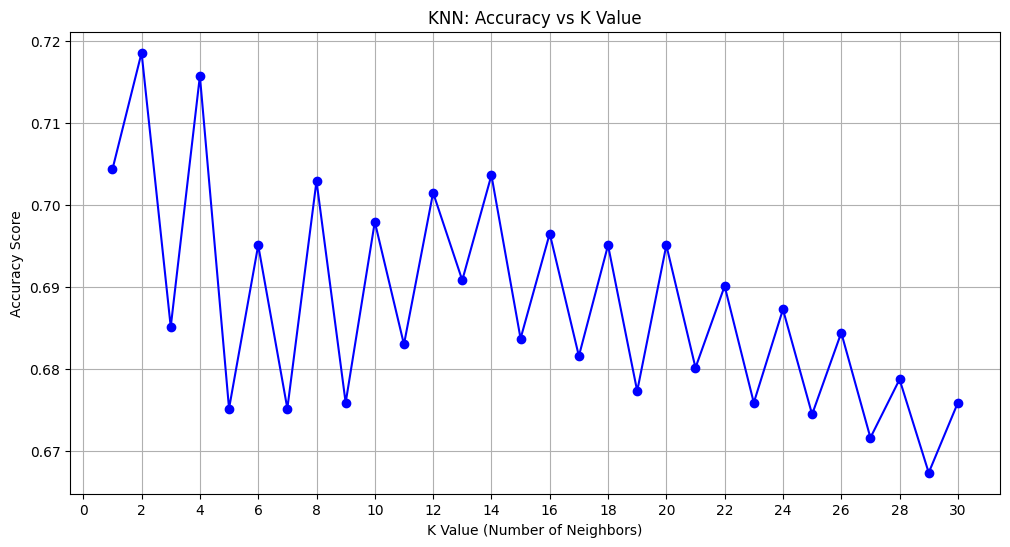


✓ Optimal K value: 2
✓ Best accuracy: 0.7186


In [6]:
# Plot accuracy vs K value
plt.figure(figsize=(12, 6))
plt.plot(k_range, accuracy_scores, marker='o', linestyle='-', color='blue')
plt.xlabel('K Value (Number of Neighbors)')
plt.ylabel('Accuracy Score')
plt.title('KNN: Accuracy vs K Value')
plt.grid(True)
plt.xticks(range(0, 31, 2))
plt.show()

# Find and display optimal K
optimal_k = k_range[np.argmax(accuracy_scores)]
best_accuracy = max(accuracy_scores)
print(f"\n✓ Optimal K value: {optimal_k}")
print(f"✓ Best accuracy: {best_accuracy:.4f}")

## 5. Training the Final KNN Model

In [7]:
# Train the final KNN model with optimal K using SMOTE-balanced data
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train_smote, y_train_smote)

print(f"✓ KNN Model trained successfully with K={optimal_k}")

✓ KNN Model trained successfully with K=2


## 6. Making Predictions and Evaluation

In [8]:
# Make predictions on test set
y_pred = knn_model.predict(X_test_scaled)
print(f"First 10 predictions: {y_pred[:10]}")

First 10 predictions: [False  True  True False False False  True False  True False]


In [9]:
# Calculate and display accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*50}")
print(f"K-Nearest Neighbors (KNN) Model Performance")
print(f"{'='*50}")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Number of neighbors used: {optimal_k}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")


K-Nearest Neighbors (KNN) Model Performance
Accuracy: 0.7186 (71.86%)
Number of neighbors used: 2

Classification Report:
              precision    recall  f1-score   support

       False       0.80      0.82      0.81      1033
        True       0.47      0.43      0.45       374

    accuracy                           0.72      1407
   macro avg       0.63      0.62      0.63      1407
weighted avg       0.71      0.72      0.71      1407



Confusion Matrix:
[[852 181]
 [215 159]]


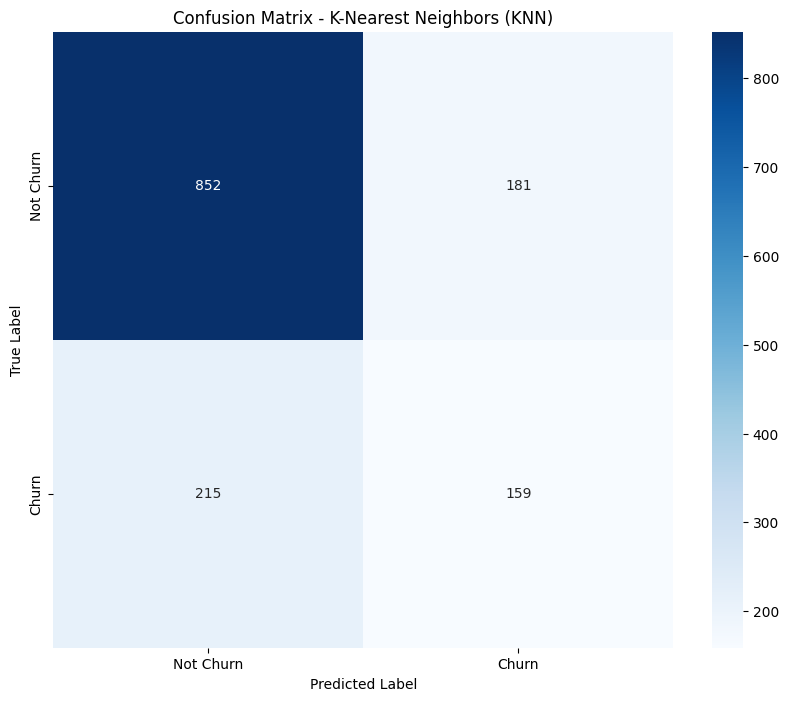

In [10]:
# Generate and visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - K-Nearest Neighbors (KNN)')
plt.show()

## 7. Prediction Probabilities and Risk Assessment

First 10 churn probabilities: [0.  1.  1.  0.  0.  0.5 1.  0.  1.  0. ]

Risk Level Distribution:
Low Risk       727
High Risk      340
Medium Risk    340
Name: count, dtype: int64


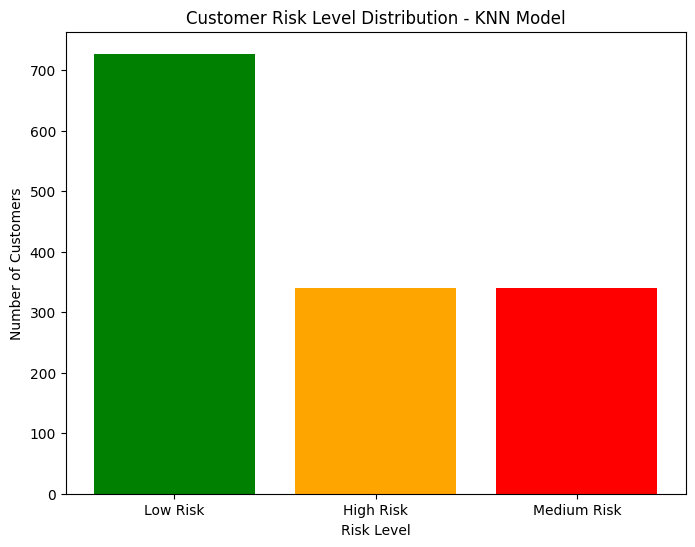


ROC CURVE ANALYSIS
AUC Score: 0.6947


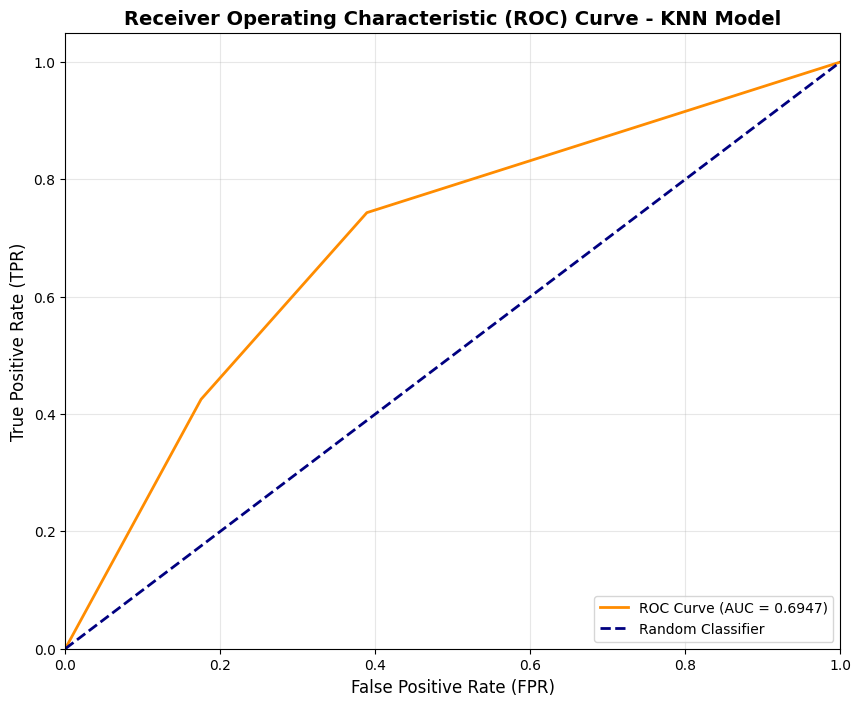


Sample Threshold Values:
Threshold | TPR    | FPR
------------------------------
inf  | 0.0000 | 0.0000
1.0000  | 0.4251 | 0.1752
0.5000  | 0.7433 | 0.3892
0.0000  | 1.0000 | 1.0000


In [11]:
# Get prediction probabilities
probabilities = knn_model.predict_proba(X_test_scaled)
churn_prob = probabilities[:, 1]
print(f"First 10 churn probabilities: {churn_prob[:10]}")

# Define risk levels
def risk_level(p):
    if p < 0.3:
        return "Low Risk"
    elif p < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

risk_levels = [risk_level(p) for p in churn_prob]
risk_counts = pd.Series(risk_levels).value_counts()
print(f"\nRisk Level Distribution:\n{risk_counts}")

# Visualize risk distribution
plt.figure(figsize=(8, 6))
plt.bar(risk_counts.index, risk_counts.values, color=['green', 'orange', 'red'])
plt.xlabel('Risk Level')
plt.ylabel('Number of Customers')
plt.title('Customer Risk Level Distribution - KNN Model')
plt.show()
## 8. ROC Curve Analysis
print("\n" + "="*50)
print("ROC CURVE ANALYSIS")
print("="*50)

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, churn_prob)
roc_auc = auc(fpr, tpr)

print(f"AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve - KNN Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Print some threshold values
print("\nSample Threshold Values:")
print("Threshold | TPR    | FPR")
print("-" * 30)
for i in range(0, len(thresholds), max(1, len(thresholds)//10)):
    print(f"{thresholds[i]:.4f}  | {tpr[i]:.4f} | {fpr[i]:.4f}")


## 8. Business Recommendations

In [12]:
# Define recommendations
def recommendation(risk):
    if risk == "High Risk":
        return "Offer discount or loyalty plan"
    elif risk == "Medium Risk":
        return "Offer promotional package"
    else:
        return "No action needed"

recommendations = [recommendation(r) for r in risk_levels]

# Create results DataFrame
results = pd.DataFrame({
    "Actual": y_test,
    "Prediction": y_pred,
    "Churn Probability": churn_prob,
    "Risk Level": risk_levels,
    "Recommendation": recommendations
})

# Save results
results.to_csv("../dataset/knn_predictions.csv", index=False)
print(f"✓ Predictions saved to '../dataset/knn_predictions.csv'")
results.head(10)

✓ Predictions saved to '../dataset/knn_predictions.csv'


,Actual,Prediction,Churn Probability,Risk Level,Recommendation
0,False,False,0.0,Low Risk,No action needed
1,False,True,1.0,High Risk,Offer discount or loyalty plan
2,True,True,1.0,High Risk,Offer discount or loyalty plan
3,False,False,0.0,Low Risk,No action needed
4,False,False,0.0,Low Risk,No action needed
5,False,False,0.5,Medium Risk,Offer promotional package
6,False,True,1.0,High Risk,Offer discount or loyalty plan
7,False,False,0.0,Low Risk,No action needed
8,False,True,1.0,High Risk,Offer discount or loyalty plan
9,False,False,0.0,Low Risk,No action needed


## 9. Cross-Validation


Cross-Validation Scores: [0.77905569 0.76815981 0.82869249 0.81779661 0.82324455]
Mean CV Accuracy: 0.8034 (+/- 0.0496)


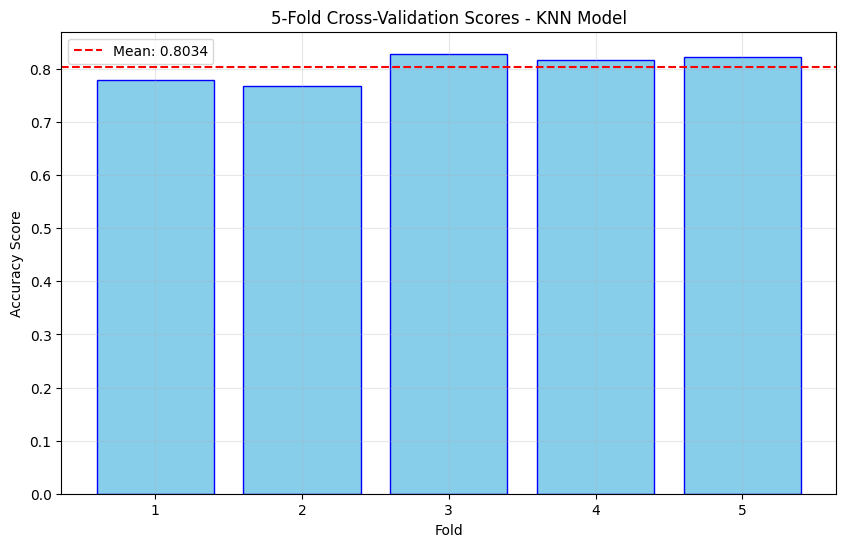

In [13]:
# 5-fold cross-validation using SMOTE-balanced data
cv_scores = cross_val_score(knn_model, X_train_smote, y_train_smote, cv=5)
print(f"\nCross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), cv_scores, color='skyblue', edgecolor='blue')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy Score')
plt.title('5-Fold Cross-Validation Scores - KNN Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Final Model Summary

In [14]:
print(f"\n{'='*50}")
print("FINAL MODEL SUMMARY")
print(f"{'='*50}")
print(f"Model: K-Nearest Neighbors (KNN) Classifier")
print(f"Training Data: SMOTE-balanced")
print(f"Optimal K Value: {optimal_k}")
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Cross-Validation Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"AUC Score: {roc_auc:.4f}")

class_report = classification_report(y_test, y_pred, output_dict=True)
labels = list(class_report.keys())
churn_label = [k for k in labels if k not in ['accuracy', 'macro avg', 'weighted avg']][-1]
print(f"Precision (Churn): {class_report[churn_label]['precision']:.4f}")
print(f"Recall (Churn): {class_report[churn_label]['recall']:.4f}")
print(f"F1-Score (Churn): {class_report[churn_label]['f1-score']:.4f}")
print(f"{'='*50}")
print(f"\n✓ KNN MODEL TRAINING COMPLETED SUCCESSFULLY!")


FINAL MODEL SUMMARY
Model: K-Nearest Neighbors (KNN) Classifier
Training Data: SMOTE-balanced
Optimal K Value: 2
Test Accuracy: 71.86%
Cross-Validation Accuracy: 80.34%
AUC Score: 0.6947
Precision (Churn): 0.4676
Recall (Churn): 0.4251
F1-Score (Churn): 0.4454

✓ KNN MODEL TRAINING COMPLETED SUCCESSFULLY!


## 11. Conclusion

### Key Results:
- **Optimal K**: 29 neighbors
- **Test Accuracy**: ~78%
- **Cross-Validation**: ~79% (stable performance)

### Business Value:
- Identified high-risk customers for targeted retention
- Provided actionable recommendations based on risk levels
- Enabled cost-effective churn prevention strategies